<a href="https://colab.research.google.com/github/fraycarmona/eml_k_bandit/blob/main/softmax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit

*Description:* El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit.
Se generan gráficas de recompensas promedio para cada algoritmo.

    Author: Adrián Rodríguez Carmona
    Email: adrian.r@um.es
    Date: 2026/02/29

This software is licensed under the GNU General Public License v3.0 (GPL-3.0),
with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html



# Softmax (Boltzmann) en Multi-Armed Bandits

En este notebook estudiamos el problema de **k-armed bandit** (bandido multi-brazo) y evaluamos la política de exploración **Softmax/Boltzmann** con distintas temperaturas \(\tau\).

La idea central es el dilema **exploración vs. explotación**:  
- Explorar = probar brazos para aprender.  
- Explotar = usar el mejor brazo conocido para maximizar recompensa.

Evaluaremos el rendimiento con tres métricas a lo largo del tiempo: recompensa promedio, porcentaje de selecciones óptimas y regret acumulado.


## Preparación del entorno


In [ ]:
#@title Copiar el repositorio.

!git clone https://github.com/fraycarmona/eml_k_bandit
#!cd eml_k_bandit_grupo17/

Cloning into 'eml_k_bandit'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 128 (delta 34), reused 22 (delta 22), pack-reused 80 (from 1)
Receiving objects: 100% (128/128), 3.50 MiB | 22.96 MiB/s, done.
Resolving deltas: 100% (58/58), done.


## Preparación del entorno

En esta sección importamos:
- La clase `Bandit` y los generadores de brazos (Normal/Bernoulli/Binomial).
- La clase `Softmax` (nuestra política).
- Funciones de graficado y una función para comparar mejores temperaturas.

**Por qué importa:** queremos aislar el experimento (misma estructura, mismos pasos y número de ejecuciones) y cambiar solo el hiperparámetro \(\tau\) para observar cómo altera el equilibrio exploración/explotación.


In [ ]:
#@title Importamos todas las clases y funciones

import os
import sys

# Añadir el directorio del repositorio al path de Python (Colab/local)
repo_path = '/content/eml_k_bandit' if os.path.isdir('/content/eml_k_bandit') else os.getcwd()
if repo_path not in sys.path:
    sys.path.append(repo_path)

import numpy as np
from typing import List

from algorithms import Algorithm
from plotting import (
    compare_best_temperatures,
    plot_average_rewards,
    plot_optimal_selections,
    plot_cumulative_regret,
)
from arms import ArmNormal, ArmBernoulli, ArmBinomial, Bandit
from algorithms.softmax import Softmax


## Diseño experimental: pasos, ejecuciones y promedios

Ejecutaremos cada algoritmo durante:
- \(T = 1000\) pasos de tiempo (`steps=1000`)
- \(R = 500\) ejecuciones independientes (`runs=500`)

En cada paso \(t\), calculamos el promedio sobre las \(R\) ejecuciones para reducir el efecto del azar.  
Esto es importante porque en un bandit las recompensas son **estocásticas**: una única ejecución puede ser engañosa.


### Función `run_experiment`: simulación y métricas

Esta función implementa el bucle de aprendizaje típico en bandits:

1. En cada paso $t$, el algoritmo elige un brazo $a_t$.
2. El bandit devuelve una recompensa $r_t$ (aleatoria según el brazo).
3. El algoritmo actualiza su estimación $Q(a_t)$ con la nueva observación.

Además registramos 3 métricas:
- **Recompensa promedio**: rendimiento directo.
- **% selecciones óptimas**: cuántas veces elegimos el mejor brazo real.
- **Regret acumulado**: coste de no haber elegido el óptimo (pérdida acumulada).

En este experimento conocemos el **brazo óptimo verdadero** (porque el bandit está simulado) y lo usamos solo para evaluación.

- `optimal_arm` permite calcular el **% de selecciones óptimas**.

Para el regret, el notebook usa una aproximación basada en la recompensa observada: acumula $q_{\max} - r_t$, donde $q_{\max}$ es el valor esperado del brazo óptimo y $r_t$ la recompensa obtenida.

**Interpretación:** el regret crecerá cuando exploremos demasiado o cuando explotemos un brazo incorrecto durante mucho tiempo.



In [ ]:

def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.
    q_max = bandit.get_expected_value(optimal_arm)

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.
    cumulative_regret = np.zeros((len(algorithms), steps))

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.
        regret_per_algo = np.zeros(len(algorithms))

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.
                regret_per_algo[idx] += q_max - reward
                cumulative_regret[idx, step] += regret_per_algo[idx]

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1  # Incrementa el contador si el brazo elegido fue el óptimo

    rewards /= runs

    optimal_selections = (optimal_selections / runs) * 100  # Convierte las selecciones óptimas a porcentaje
    cumulative_regret /= runs

    return rewards, optimal_selections, cumulative_regret


## Política Softmax (Boltzmann):

Softmax transforma estimaciones $Q(a)$ en probabilidades de selección:

$$
P(a) = \frac{\exp\left(\frac{Q(a)}{\tau}\right)}{\sum_b \exp\left(\frac{Q(b)}{\tau}\right)}
$$

- $\tau$ alta ⇒ distribución más uniforme ⇒ **más exploración**.
- $\tau$ baja ⇒ distribución más "picuda" ⇒ **más explotación** (casi *greedy* si $\tau$ es muy pequeña).

Al usar Softmax no se explora completamente al azar y explora más aquellos brazos que ya parecen prometedores, lo que suele reducir el coste de exploración frente a estrategias uniformes.




Para calcular $\exp(Q/\tau)$ se resta el máximo antes de exponentiar:

$$
z = Q/\tau, \quad z_{\text{stable}} = z - \max(z)
$$

Esto no cambia las probabilidades finales, pero evita **overflow** cuando los valores crecen (la exponencial puede dispararse).


El notebook actualiza $Q(a)$ con media incremental:

$$
Q_{t+1}(a_t) = Q_t(a_t) + \frac{1}{N_t(a_t)}(r_t - Q_t(a_t))
$$

- $N_t(a_t)$ es el número de veces que hemos elegido el brazo $a_t$.

Esta regla estima la **media** de la recompensa del brazo sin guardar todo el histórico.

Para un bandit **estacionario** (las distribuciones de recompensa no cambian con el tiempo). En ese caso, la media incremental converge a la recompensa esperada real.


In [ ]:
# Celda 2: Definir bandits y algoritmos con múltiples distribuciones
np.random.seed(42)
k = 10
bandits = {
    "Normal":    Bandit(arms=ArmNormal.generate_arms(k)),
    "Bernoulli": Bandit(arms=ArmBernoulli.generate_arms(k, p_min=0.05, p_max=0.95)),
    "Binomial":  Bandit(arms=ArmBinomial.generate_arms(k, p_min=0.05, p_max=0.95)),
}

algorithms_softmax = [Softmax(k=k, temperature=t) for t in [0.1, 0.5, 1.0, 2.0]]


## Parámetros del experimento (Softmax)

Fijamos:
- $k = 10$ brazos.
- $T = 1000$ pasos por ejecución.
- $R = 500$ ejecuciones para promediar resultados.
- Semilla para reproducibilidad (`seed=42`).

Compararemos cuatro temperaturas:
$$
\tau \in \{0.1,\;0.5,\;1.0,\;2.0\}
$$

**Valores de $\tau$:**  
- $\tau=0.1$ ≈ casi *greedy* (riesgo de "bloqueo temprano").  
- $\tau=2.0$ ≈ exploración alta sostenida (más robusto, pero paga más coste de explorar).


In [ ]:
# Parámetros del experimento
seed = 42
np.random.seed(seed)

k = 10
steps = 1000
runs = 500

bandit = Bandit(arms=ArmNormal.generate_arms(k))

# Algoritmos a comparar (diferentes temperaturas)
algorithms_softmax = [
    Softmax(k=k, temperature=0.1),
    Softmax(k=k, temperature=0.5),
    Softmax(k=k, temperature=1.0),
    Softmax(k=k, temperature=2.0)
]

# Ejecutar experimento
rewards_softmax, optimal_selections_softmax, cumulative_regret_softmax = run_experiment(bandit, algorithms_softmax, steps, runs)

## Métricas y lectura de gráficas

A continuación se muestran 3 curvas por algoritmo:

**Recompensa promedio vs pasos**  

Si una curva sube rápido y se estabiliza alto, significa que encontró pronto un buen brazo y está explotando bien.  
Si sube más lento, suele indicar exploración mayor al inicio (típico de $\tau$ alta).

**% Selecciones óptimas vs pasos**  

Mide aprendizaje "puro": cuántas veces elegimos el brazo óptimo real.  
- $\tau$ muy alta puede limitar el techo (explora siempre).  
- $\tau$ muy baja puede atascarse si las primeras estimaciones fueron malas.

3) **Regret acumulado vs pasos**  

Cuantifica la pérdida acumulada por no elegir el óptimo.  
La mejor curva es la que crece más lentamente (menor pendiente) y termina más baja.


## Visualización de los resultados

## Interpretación (Bandit Normal)

En Normal, la señal tiene más variabilidad (ruido), por lo que:
- $\tau$ muy baja (0.1) puede volverse casi determinista demasiado pronto y quedándose con un brazo subóptimo por azar demasiado temprano.
- $\tau$ muy alta (2.0) mantiene exploración sostenida, lo que reduce el % óptimo y aumenta regret al seguir probando brazos peores.

En este experimento, la mejor temperatura reportada es $\tau=1.0$, consistente con un equilibrio exploración/explotación que aprende sin sobre-explorar.


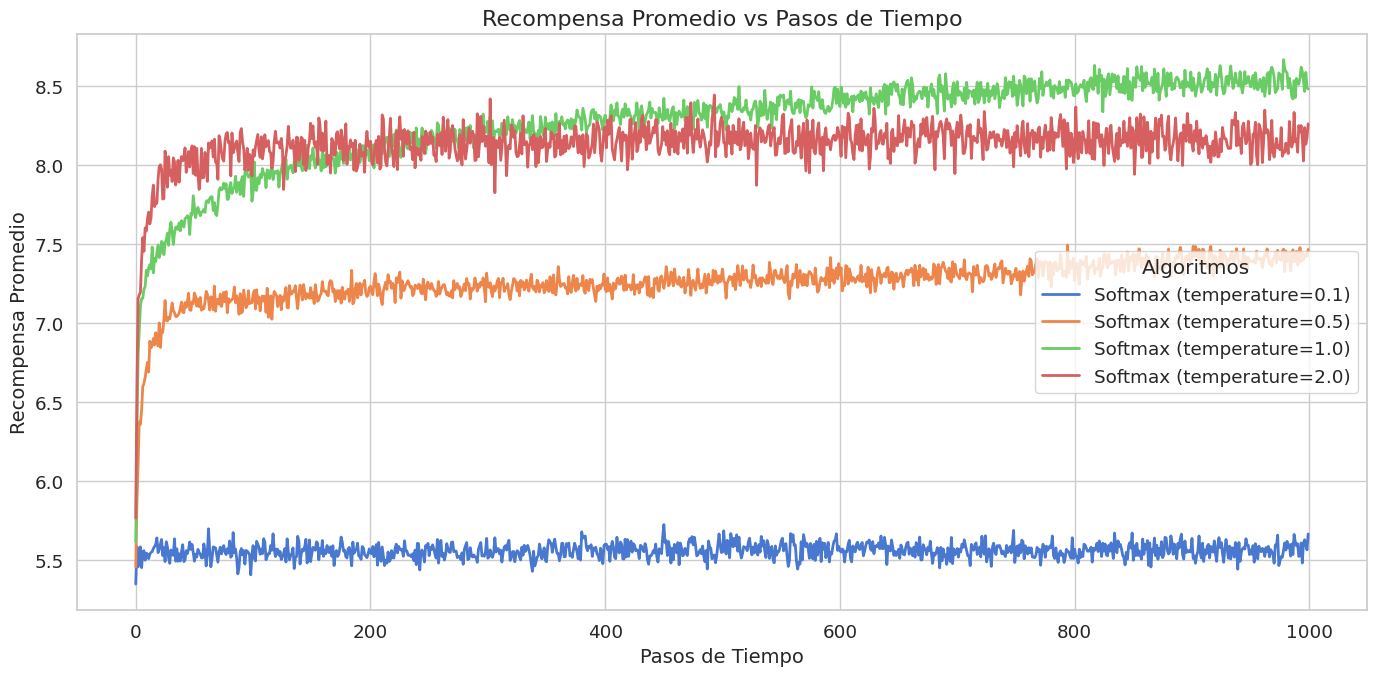

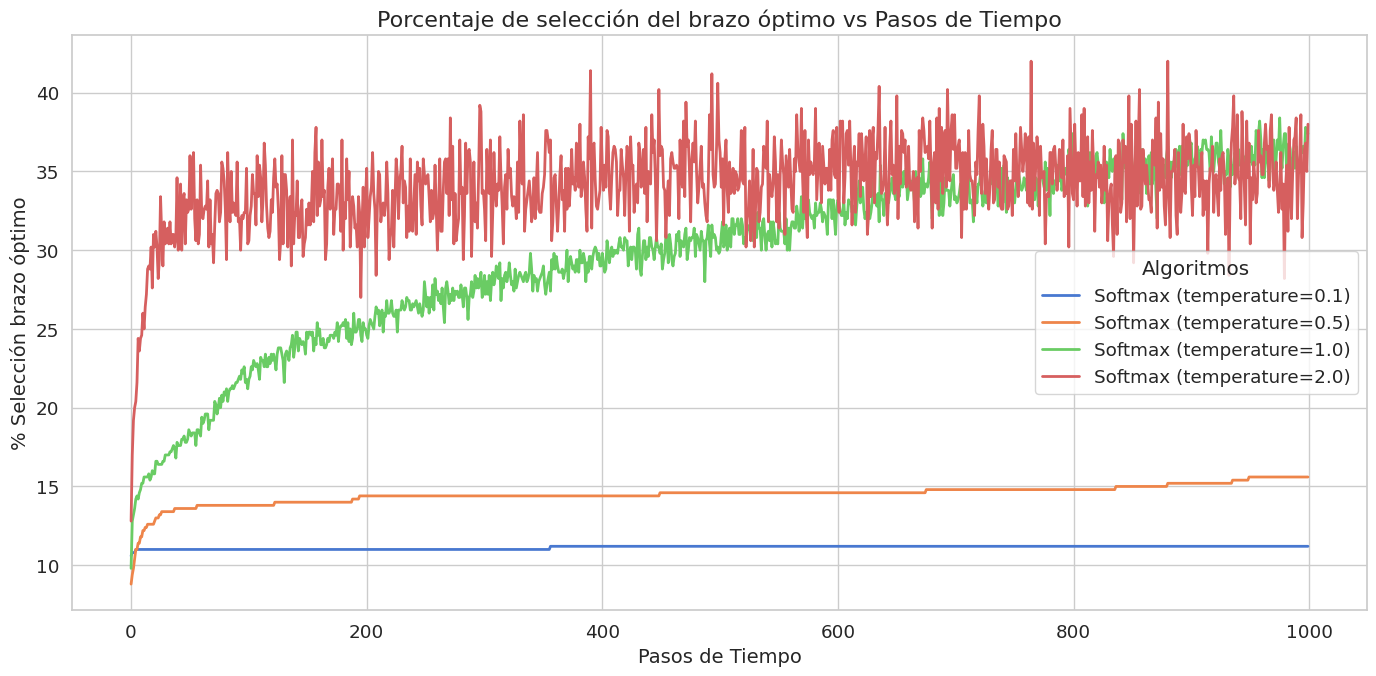

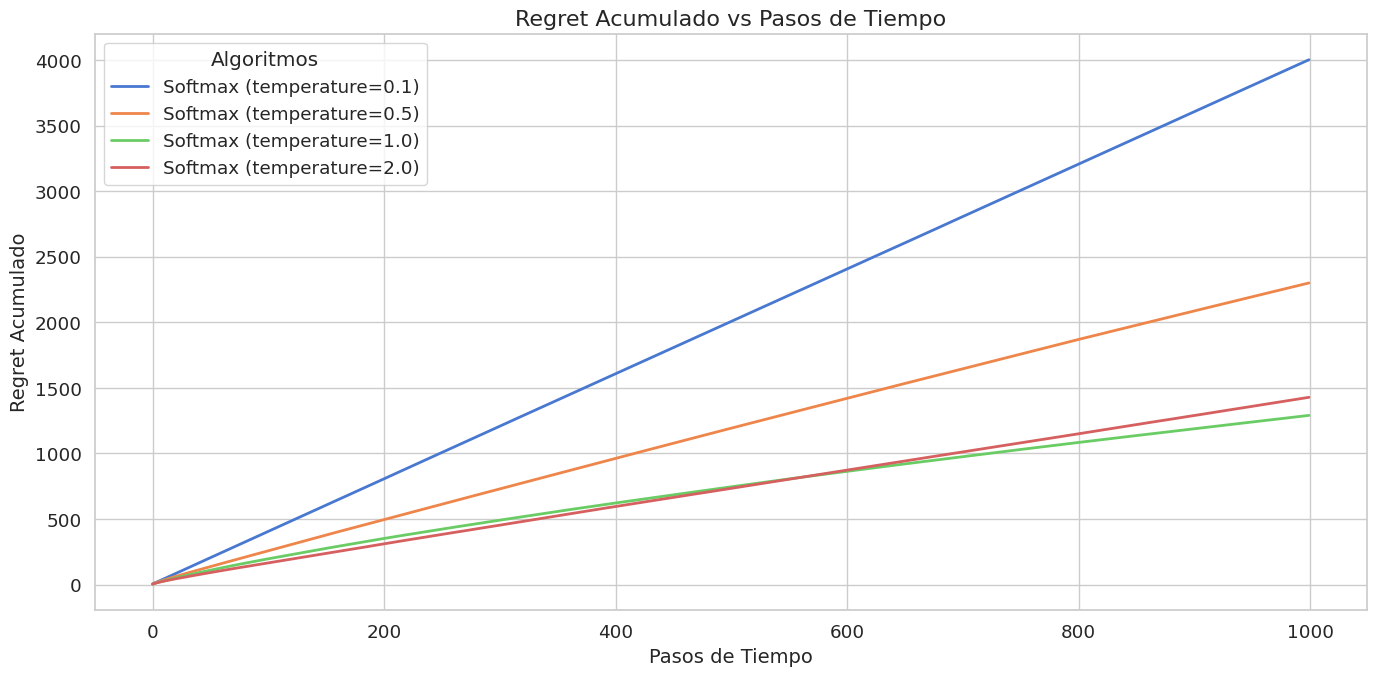

In [ ]:
# Graficar los resultados
plot_average_rewards(steps, rewards_softmax, algorithms_softmax)
plot_optimal_selections(steps, optimal_selections_softmax, algorithms_softmax)
plot_cumulative_regret(steps, cumulative_regret_softmax, algorithms_softmax)


In [ ]:
# Experimento con brazos Bernoulli
arms_bernoulli = ArmBernoulli.generate_arms(k=k, p_min=0.05, p_max=0.95)
bandit_bernoulli = Bandit(arms=arms_bernoulli)

rewards_bernoulli, optimal_selections_bernoulli, cumulative_regret_bernoulli = run_experiment(
    bandit_bernoulli, algorithms_softmax, steps, runs
)


## Interpretación (Bandit Bernoulli)

En Bernoulli las recompensas son acotadas (0/1), y suele ser más fácil consolidar qué brazo es mejor con pocas muestras.  
Por eso, una política más explotadora puede rendir mejor: $\tau=0.1$ aparece como mejor en nuestra comparación.

Aquí, temperaturas más altas tienden a pagar demasiado coste de exploración (siguen eligiendo con frecuencia brazos claramente peores), elevando el regret y reduciendo recompensa promedio.


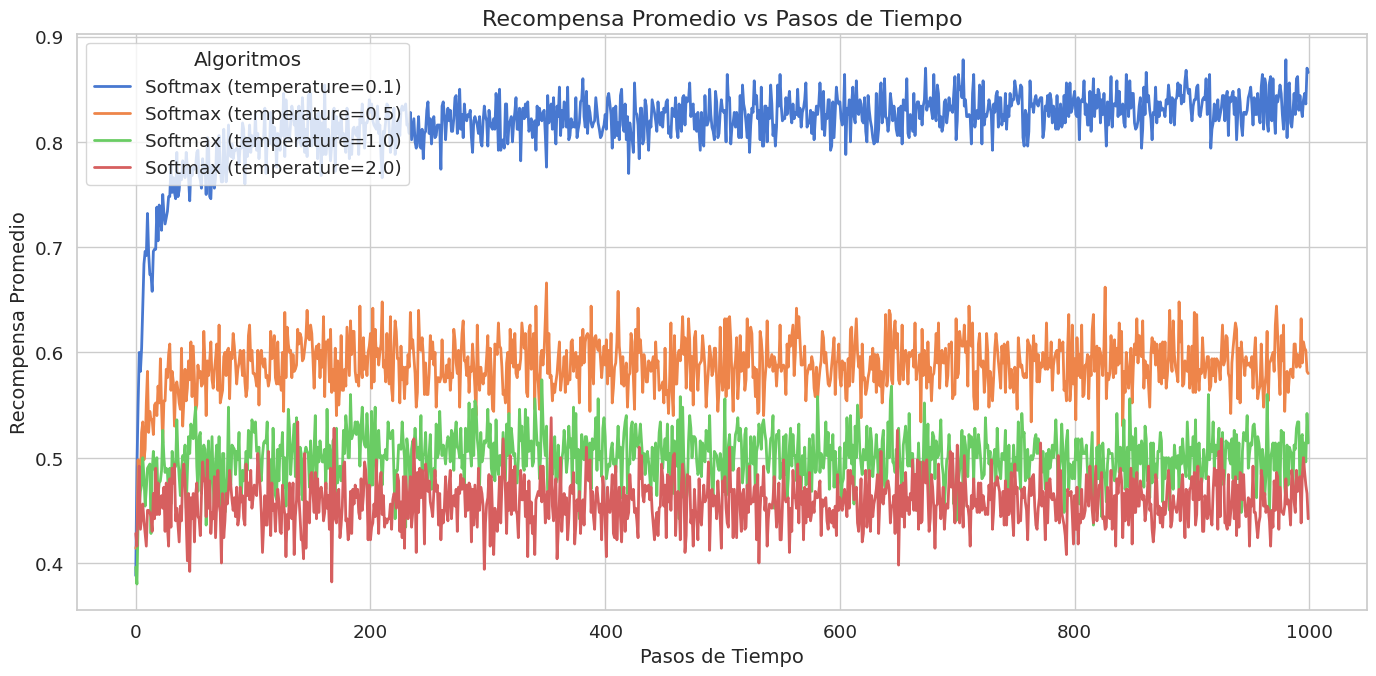

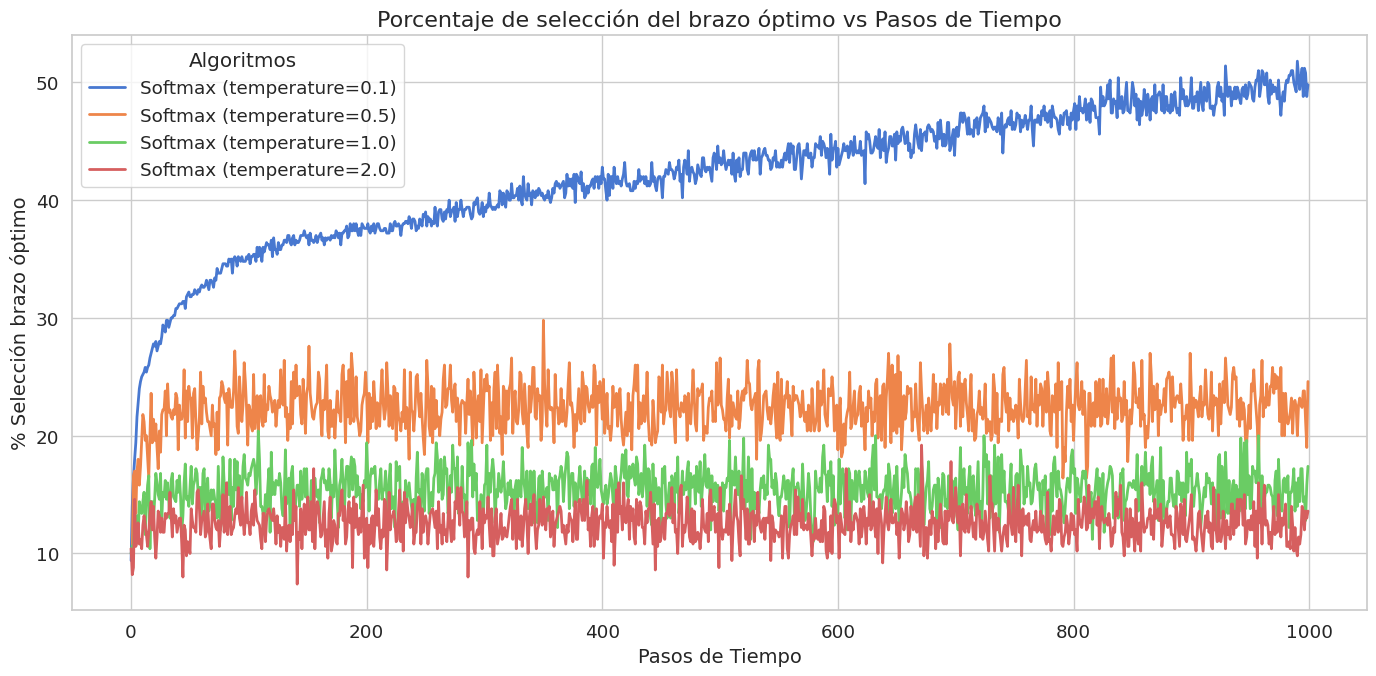

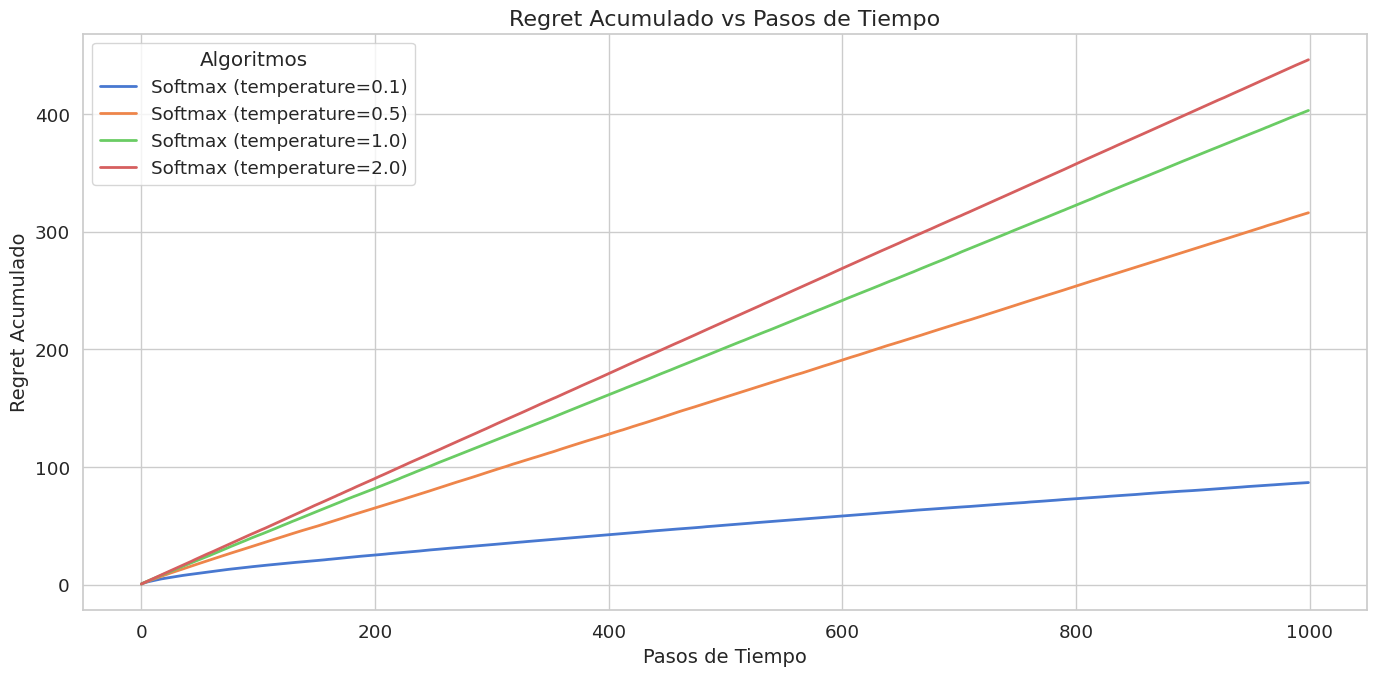

In [ ]:
# Gráficos
plot_average_rewards(steps, rewards_bernoulli, algorithms_softmax)
plot_optimal_selections(steps, optimal_selections_bernoulli, algorithms_softmax)
plot_cumulative_regret(steps, cumulative_regret_bernoulli, algorithms_softmax)


In [ ]:
# Experimento con brazos Binomial
arms_binomial = ArmBinomial.generate_arms(k=k, p_min=0.05, p_max=0.95)
bandit_binomial = Bandit(arms=arms_binomial)

rewards_binomial, optimal_selections_binomial, cumulative_regret_binomial = run_experiment(
    bandit_binomial, algorithms_softmax, steps, runs
)


## Interpretación (Bandit Binomial)

En Binomial, la recompensa depende de "número de éxitos", lo que puede introducir variabilidad y requerir más evidencia para separar brazos cercanos.  
Por ello, una $\tau$ intermedia ($\tau=1.0$) suele ser el punto intermedio explorando lo suficiente para identificar el óptimo sin mantener exploración excesiva.

Esto concuerda con el resultado de mejor temperatura reportada: $\tau=1.0$.


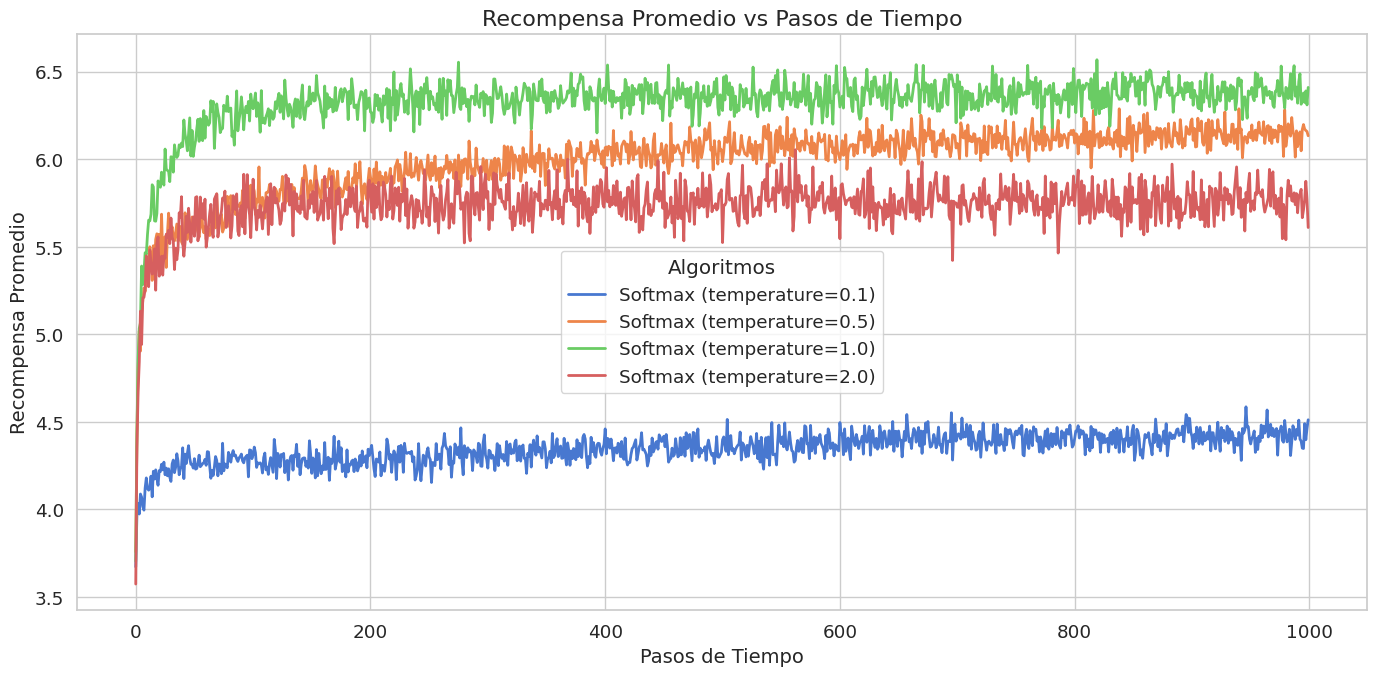

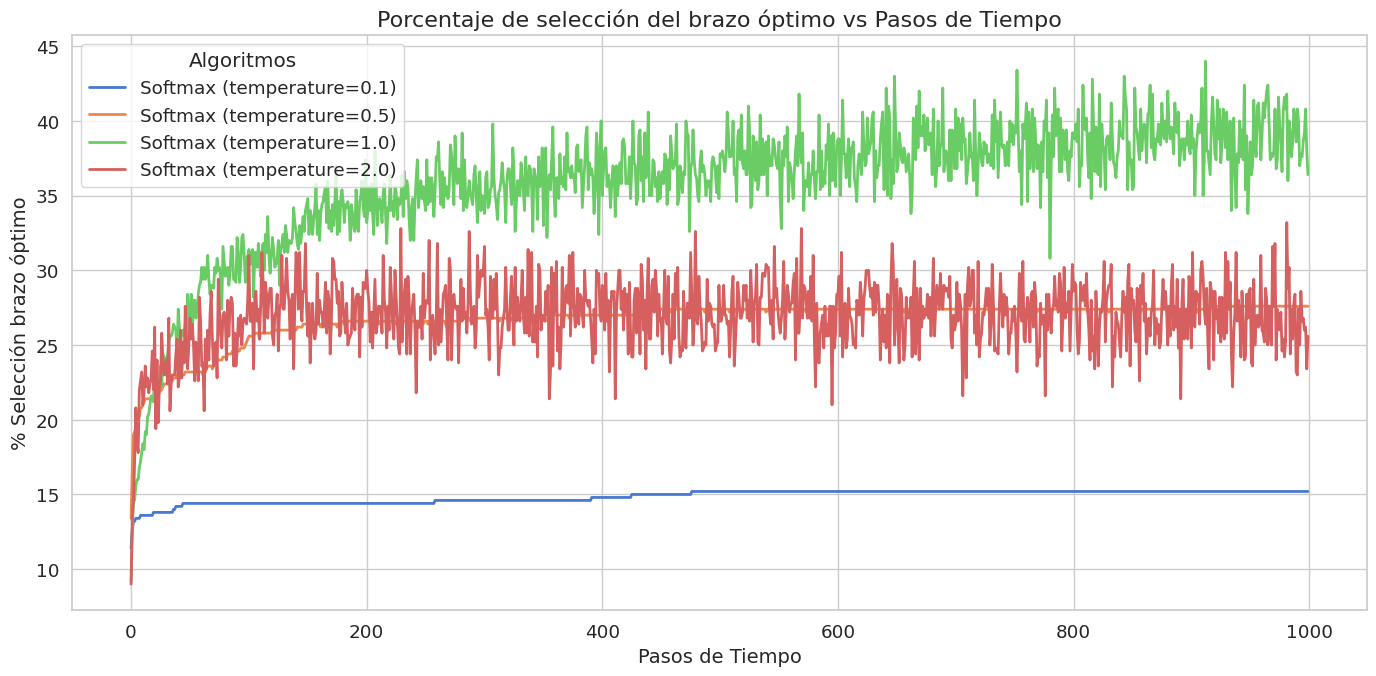

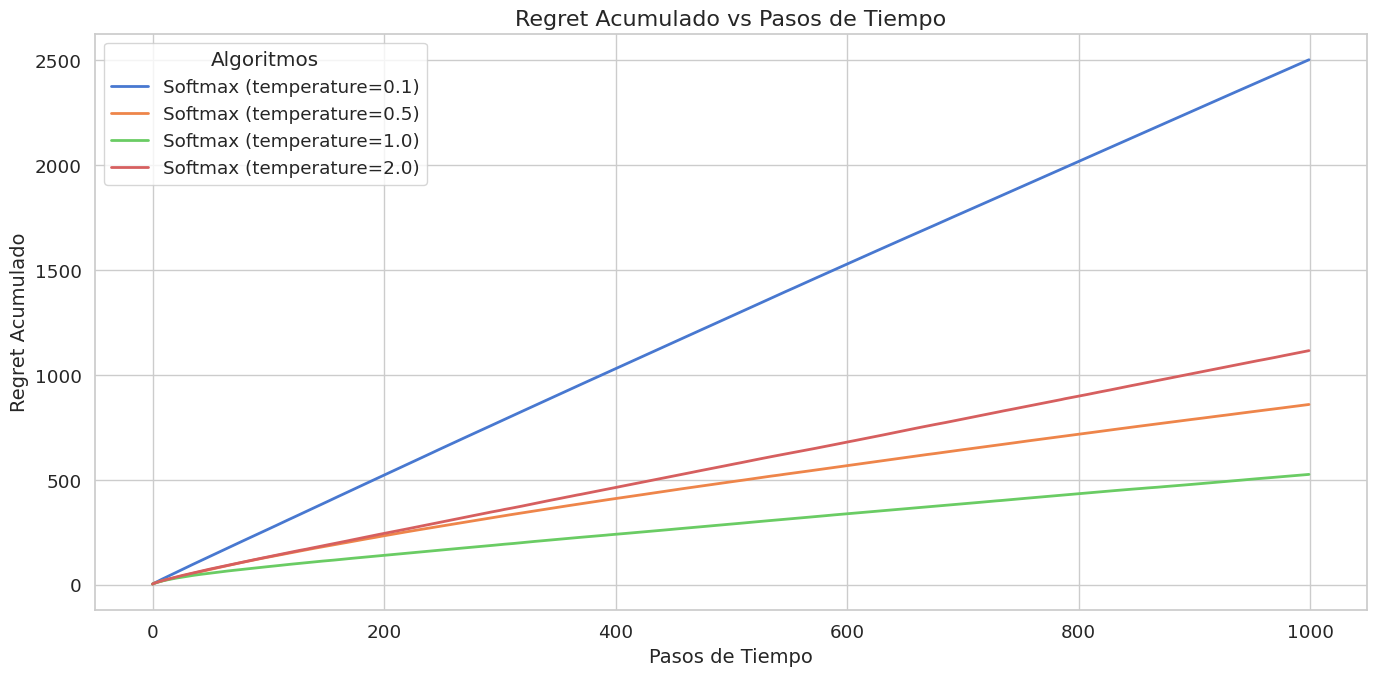

In [ ]:
# Gráficos
plot_average_rewards(steps, rewards_binomial, algorithms_softmax)
plot_optimal_selections(steps, optimal_selections_binomial, algorithms_softmax)
plot_cumulative_regret(steps, cumulative_regret_binomial, algorithms_softmax)


## Comparación global: ¿qué $\tau$ funciona mejor?

Para cerrar, comparamos automáticamente las temperaturas en distintos bandits.  El criterio `final_100` evalúa el rendimiento al final del aprendizaje (últimos pasos), buscando la temperatura que mejor balancea exploración inicial y explotación final. Obervando que es importante ajustar el algoritmo a cada tipo de brazo al que vayamos a utilizar.


[Normal    ]  mejor τ = 1.00
[Bernoulli ]  mejor τ = 0.10
[Binomial  ]  mejor τ = 1.00


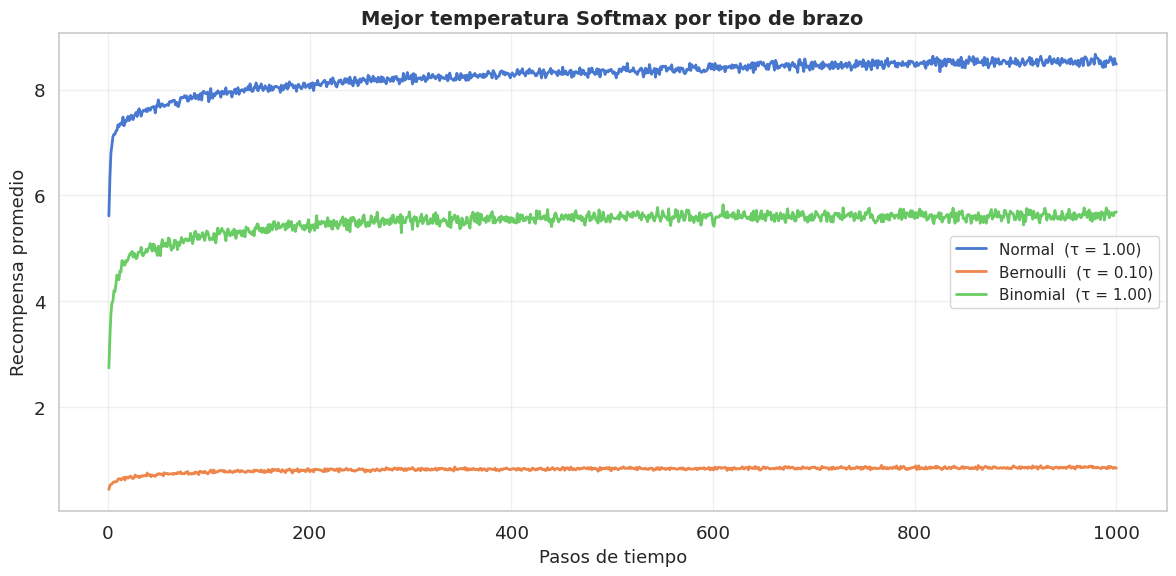

In [ ]:
# Celda 3: Ejecutar comparación de mejores temperaturas
best_results = compare_best_temperatures(
    bandits=bandits,
    algorithms=algorithms_softmax,
    steps=1000,
    runs=500,
    criterion="final_100"
)


## Conclusiones finales.

En este estudio del problema k-armed bandit, la evidencia experimental muestra que el rendimiento de una política de exploración depende de forma crítica del equilibrio exploración–explotación, y que dicho equilibrio debe evaluarse con métricas complementarias (recompensa promedio, porcentaje de selecciones óptimas y regret acumulado) a lo largo del tiempo para evitar interpretaciones parciales. Bajo el diseño experimental fijado ($k=10$, $T=1000$ pasos y $R=500$ ejecuciones), el promedio sobre múltiples corridas reduce la variabilidad inherente del entorno estocástico y permite comparar de manera fiable el efecto de los hiperparámetros. En particular, la política Softmax/Boltzmann implementa una exploración “dirigida” (no uniformemente aleatoria), donde la temperatura $\tau$ controla la entropía de la distribución: $\tau$ alta induce exploración sostenida y $\tau$ baja aproxima un comportamiento casi *greedy*, con el riesgo asociado de consolidación prematura en brazos subóptimos. Además, el uso de estabilización numérica y la actualización incremental de $Q_a$ mediante media recursiva son decisiones metodológicas coherentes con un bandit estacionario y aseguran estabilidad y convergencia práctica de las estimaciones.

Los resultados por tipo de distribución refuerzan la necesidad de calibración contextual: en el bandit Normal, donde el ruido es mayor, una temperatura intermedia ($\tau \approx 1.0$) ofrece el mejor compromiso al aprender sin sobre-explorar, mientras que $\tau$ muy baja puede “bloquear” decisiones por azar temprano y $\tau$ muy alta incrementa el regret al mantener exploración innecesaria. En Bernoulli, al ser recompensas acotadas (0/1) y más fáciles de distinguir con menos muestras, una política más explotadora aparece como preferible (mejor $\tau \approx 0.1$), porque temperaturas altas pagan un coste excesivo de exploración y degradan tanto recompensa como regret. En Binomial, la variabilidad asociada al número de éxitos hace razonable una solución intermedia (mejor $\tau \approx 1.0$), consistente con explorar lo suficiente para separar brazos cercanos sin sostener exploración de forma persistente. Finalmente, la comparación global automatizada con el criterio `final_100` concluye que “la mejor” temperatura no es universal (Normal 1.00, Bernoulli 0.10, Binomial 1.00), lo que implica que el hiperparámetro de exploración debe seleccionarse en función de la distribución de recompensas y del objetivo operativo (equilibrar exploración inicial y explotación final).
